# 01 — Loss(v) 정의 · 데이터 품질 진단 · 기준선 수립

**목적**: 모델을 만들기 전에 (1) 타깃을 정확히 정의하고 (2) 쓸 수 없는 데이터를 걸러내고
(3) 넘어야 할 최소 기준을 확정한다.

## 구성
| 절 | 내용 |
|---|---|
| 1 | 접근로 구조 검증 → Av144 메타데이터 오류 교정 |
| 2 | 방위 판별 (AvenueName 을 신뢰하지 않고 교통 패턴으로 확인) |
| 3 | **데이터 품질 진단 4단계** |
| 4 | Loss 계산 (부호 유지, 품질 필터 적용) |
| 5 | 월별 가용 현황 및 시간순 분할 |
| 6 | 기준선 4종 성능 측정 |
| 7 | persistence 실패 원인 분해 |
| 8 | 시각화 및 채택 기준선 |

**핵심 원칙**: 절대 성능이 아니라 '기준선 대비 개선률'로 평가한다.

## 0. 설정

In [1]:
RAW_MIGEUM  = "../data/raw/미금역사거리.csv"
RAW_DONGMAK = "../data/raw/동막교사거리.csv"
REF_AVENUE  = "../data/raw/접근로정보.csv"
OUT_DIR     = "../outputs/01_기준선"

# 시간순 분할: 2024년까지 학습 / 2025년 평가
TEST_START    = "2025-01-01"
COMMUTE_HOURS = [7, 8, 9, 17, 18, 19]
VOLUME_FLOOR  = 0.30    # 동막교 총량이 시간대 평소값의 30% 미만이면 제외

### 로그 기록 방식
`sys.stdout` 을 교체하면 JupyterLab 이 출력을 어느 셀에 표시할지 추적하지 못해
**셀 아래에 아무것도 보이지 않는다.** `print` 를 감싸서 화면 출력은 그대로 두고
내용만 모아 두었다가 마지막에 파일로 저장한다.

In [2]:
import os, sys, warnings, builtins
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
os.makedirs(OUT_DIR, exist_ok=True)
for f in ["Malgun Gothic","NanumGothic","AppleGothic"]:
    try: matplotlib.rc("font", family=f); break
    except Exception: pass
matplotlib.rcParams["axes.unicode_minus"]=False

_LOG=[]
def print(*args, sep=" ", end="\n", **kw):
    _LOG.append(sep.join(str(a) for a in args)+end)
    builtins.print(*args, sep=sep, end=end, **kw)
def save_log(path):
    with open(path,"w",encoding="utf-8") as fh: fh.write("".join(_LOG))
    builtins.print(f"로그 저장: {path}  ({len(_LOG)}줄)")
def sec(t): print("\n"+"="*78+"\n"+t+"\n"+"="*78)

def load(p):
    d=pd.read_csv(p, encoding="utf-8-sig")
    d.columns=[c.strip().strip('"') for c in d.columns]
    return d

mg, dm = load(RAW_MIGEUM), load(RAW_DONGMAK)
df = pd.concat([mg, dm], ignore_index=True)
df["dt"] = pd.to_datetime(df["CollectedDate"]).dt.floor("h")
full = pd.date_range(df.dt.min(), df.dt.max(), freq="h")
print(f"미금역 {len(mg):,}행 / 동막교 {len(dm):,}행 / 합계 {len(df):,}행")
print(f"기간 {df.dt.min()} ~ {df.dt.max()}  ({len(full):,} 시간슬롯)")
print(f"셀 내부 결측값: {int(df.isna().sum().sum())}건")
key=["IntersectionSeq","AvenueSeq","dt","LaneNum","CarModelType","MovementType"]
print(f"중복 레코드: {int(df.duplicated(subset=key).sum())}건")

미금역 1,657,362행 / 동막교 1,104,658행 / 합계 2,762,020행
기간 2023-11-07 16:00:00 ~ 2025-09-04 12:00:00  (16,005 시간슬롯)
셀 내부 결측값: 0건
중복 레코드: 0건


## 1. 접근로 구조 확정 — Av144 오류 교정

`CoupleLinkID`(자기 다리의 진출 링크)를 이동류별 진출링크에서 역산해 검증한다.
진출링크 후보 4개 중 직진·좌회전·우회전이 쓰지 않는 나머지 하나가
'자기 다리 진출링크'(=유턴이 나가는 곳)여야 한다.

In [3]:
sec("1. 접근로 구조 검증 및 교정")
ref = load(REF_AVENUE)
ref = ref[ref.IntersectionSeq.isin([37,48])].set_index("AvenueSeq")
own_exit={}
for iid in [37,48]:
    sub=ref[ref.IntersectionSeq==iid]; allex=set()
    for _,r in sub.iterrows():
        allex |= {r.StraightLinkID, r.TurnLeftLinkID, r.TurnRightLinkID}
    allex={int(x) for x in allex if pd.notna(x)}
    for av,r in sub.iterrows():
        used={int(x) for x in [r.StraightLinkID,r.TurnLeftLinkID,r.TurnRightLinkID] if pd.notna(x)}
        own_exit[av]=list(allex-used)[0]

print(f"{'접근로':<8}{'이름':<20}{'역산값':>12}{'파일값':>12}   판정")
for av,r in ref.iterrows():
    ok = "OK" if own_exit[av]==r.CoupleLinkID else "<<< 파일 오류"
    print(f"Av{av:<6}{r.AvenueName:<20}{own_exit[av]:>12}{int(r.CoupleLinkID):>12}   {ok}")
print("\n→ Av144 의 CoupleLinkID 는 Av145 의 값이 잘못 복사된 것. 역산값으로 교정한다.")

def exit_link(av,mv):
    r=ref.loc[av]
    return int({1:r.StraightLinkID,2:r.TurnLeftLinkID,3:r.TurnRightLinkID,4:own_exit[av]}[mv])


1. 접근로 구조 검증 및 교정
접근로     이름                           역산값         파일값   판정
Av142   청송마을 사거리 방면           2060032900  2060032900   OK
Av143   까치마을사거리 방면            2060032700  2060032700   OK
Av144   미금역 방면                2060030900  2060032400   <<< 파일 오류
Av145   정자일로 방면               2060032400  2060032400   OK
Av183   동막교삼거리 방면             2060021500  2060021500   OK
Av184   오리공원 방면               2060020100  2060020100   OK
Av185   오리역 방면                2060019400  2060019400   OK
Av186   경기고속삼거리 방면            2060021200  2060021200   OK

→ Av144 의 CoupleLinkID 는 Av145 의 값이 잘못 복사된 것. 역산값으로 교정한다.


## 2. 방위 판별

AvenueName 은 신뢰할 수 없다. Av144 는 '미금역 방면'이지만 실제로는 남측 다리다.
- 남측 다리로 **진입** = 북행 통행 → **오전 편중**
- 북측 다리로 **진입** = 남행 통행 → **저녁 편중**

In [4]:
sec("2. 방위 판별")
import holidays
kr=set(holidays.KR(years=[2023,2024,2025]).keys())
df["date"]=df.dt.dt.date
df["wd"]=(df.dt.dt.dayofweek<5)&(~df.date.isin(kr))
st=df[df.wd&(df.MovementType==1)]
nd=st.groupby("AvenueSeq")["date"].nunique()
prof=st.groupby(["AvenueSeq", st.dt.dt.hour])["Volume"].sum().unstack(0).div(nd,axis=1)
print(f"{'접근로':<8}{'이름':<20}{'오전7-9':>10}{'저녁17-19':>11}{'저녁/오전':>10}  판정")
for av in [142,143,144,145,183,184,185,186]:
    am,pm=prof[av].loc[7:9].sum(), prof[av].loc[17:19].sum()
    tag="남측(북행 진입)" if pm/am<0.85 else ("북측(남행 진입)" if pm/am>1.05 else "-")
    print(f"Av{av:<6}{ref.loc[av,'AvenueName']:<20}{am:>10.0f}{pm:>11.0f}{pm/am:>10.2f}  {tag}")
sv=df[df.MovementType==1].groupby("AvenueSeq")["Volume"].sum()
print("\n[간선축 판별] 대향쌍 직진 총량")
print(f"  교차로37: (142,144)={sv[142]+sv[144]:>12,}   (143,145)={sv[143]+sv[145]:>12,}")
print(f"  교차로48: (183,185)={sv[183]+sv[185]:>12,}   (184,186)={sv[184]+sv[186]:>12,}")
print("\n→ 확정: 37 남측=Av144, 북측=Av142 / 48 북측=Av183, 남측=Av185")


2. 방위 판별
접근로     이름                       오전7-9    저녁17-19     저녁/오전  판정
Av142   청송마을 사거리 방면               2081       2344      1.13  북측(남행 진입)
Av143   까치마을사거리 방면                1343        850      0.63  남측(북행 진입)
Av144   미금역 방면                    2678       1534      0.57  남측(북행 진입)
Av145   정자일로 방면                   1543       1597      1.03  -
Av183   동막교삼거리 방면                 2678       3275      1.22  북측(남행 진입)
Av184   오리공원 방면                    316        241      0.76  남측(북행 진입)
Av185   오리역 방면                    3838       2567      0.67  남측(북행 진입)
Av186   경기고속삼거리 방면                 357        531      1.49  북측(남행 진입)

[간선축 판별] 대향쌍 직진 총량
  교차로37: (142,144)=  14,119,920   (143,145)=   8,824,693
  교차로48: (183,185)=  17,092,661   (184,186)=   1,952,783

→ 확정: 37 남측=Av144, 북측=Av142 / 48 북측=Av183, 남측=Av185


## 3. 데이터 품질 진단 — 4단계

'결측값 0건'은 **셀 안에 빈칸이 없다**는 뜻일 뿐이다.
**있어야 할 행이 통째로 빠진 것**은 그것만으로 잡히지 않는다.

| 단계 | 문제 유형 | 탐지 방법 |
|---|---|---|
| 3-1 | 시각 자체가 없음 | 전체 시간축과 대조 |
| 3-2 | 접근로 일부만 기록 | 시각별 접근로 개수 |
| 3-3 | 접근로는 다 있는데 값이 붕괴 | 시간대 평소값 대비 비율 |
| 3-4 | **Loss 구성 조합 중 일부가 장기 소실** | **조합별 전수 감사** |

**3-4 가 특히 중요하다.** 미금역은 Av142(직진) 교통량이 커서, Av143 이 통째로 사라져도
총량으로는 정상처럼 보인다. 총량이 아니라 **계산에 필요한 조각이 다 있는지**를 봐야 한다.

In [5]:
sec("3-1. 시각 누락 진단")
have={iid:set(df.loc[df.IntersectionSeq==iid,"dt"].unique()) for iid in [37,48]}
for iid,name in [(37,"미금역사거리"),(48,"동막교사거리")]:
    miss=[t for t in full if t not in have[iid]]
    print(f"{name}({iid}): 관측 {len(have[iid]):,} / 누락 {len(miss):,} ({len(miss)/len(full)*100:.2f}%)")
print("\n→ 미금역은 사실상 완전. 시각 누락은 동막교에 집중.")


3-1. 시각 누락 진단
미금역사거리(37): 관측 16,001 / 누락 4 (0.02%)
동막교사거리(48): 관측 13,472 / 누락 2,533 (15.83%)

→ 미금역은 사실상 완전. 시각 누락은 동막교에 집중.


In [6]:
sec("3-2. 접근로 누락 진단")
cnt=df.groupby(["IntersectionSeq","dt"])["AvenueSeq"].nunique().unstack(0).reindex(full)
tot=df.groupby(["IntersectionSeq","dt"])["Volume"].sum().unstack(0).reindex(full)
is_wd=(full.dayofweek<5)&(~pd.Series(full.date,index=full).isin(kr)).values
is_com=is_wd & pd.Series(full.hour,index=full).isin(COMMUTE_HOURS).values

for iid,name in [(37,"미금역"),(48,"동막교")]:
    s=pd.DataFrame({"n":cnt[iid],"tot":tot[iid]},index=full)[is_com].dropna()
    print(f"\n[{name}] 출퇴근 시각의 접근로 개수별 총교통량")
    print(s.groupby("n")["tot"].agg(시각수="size", 총량중앙값="median").round(0).to_string())
print("\n→ 동막교는 접근로 1~3개만 기록된 시각의 총량이 정상의 0.5% 수준으로 붕괴.")
print("   미금역은 3개만 기록돼도 총량 약 95% 유지 (누락은 대부분 부축 Av143).")


3-2. 접근로 누락 진단

[미금역] 출퇴근 시각의 접근로 개수별 총교통량
      시각수   총량중앙값
n                
2.0    46  2364.0
3.0   479  3781.0
4.0  2169  4000.0

[동막교] 출퇴근 시각의 접근로 개수별 총교통량
      시각수   총량중앙값
n                
1.0    21     1.0
2.0    28     7.0
3.0    32    19.0
4.0  2214  3474.0

→ 동막교는 접근로 1~3개만 기록된 시각의 총량이 정상의 0.5% 수준으로 붕괴.
   미금역은 3개만 기록돼도 총량 약 95% 유지 (누락은 대부분 부축 Av143).


In [7]:
sec("3-3. 총량 붕괴 진단")
full4={iid:(cnt[iid]==4).fillna(False) for iid in [37,48]}
ratio={}
for iid,name,th in [(37,"미금역",0.5),(48,"동막교",0.3)]:
    bh=tot[iid].where(full4[iid]).groupby(full.hour).median()
    ratio[iid]=tot[iid]/pd.Series([bh[h] for h in full.hour],index=full)
    s=ratio[iid][full4[iid]&is_com].dropna()
    print(f"\n[{name}] 접근로 4개 완전기록 시각의 '시간대 평소값 대비 비율'")
    print(s.describe(percentiles=[.01,.05,.25,.5,.95]).round(2).to_string())
    print("  임계값별 건수:", {f"<{t}":int((s<t).sum()) for t in [0.3,0.4,0.5,0.6,0.7]})
    low=s[s<th]; d=pd.Series(low.index.date).value_counts()
    print(f"  <{th} 인 {len(low)}건이 {len(d)}개 날짜에 분포 "
          f"(날짜당 평균 {len(low)/max(len(d),1):.1f}건)")

print("\n→ 동막교: 0.3 근처에 뚜렷한 절벽(49건→50건). 2024-10~11 에 몰려 반복 → 장비 결함, 제외")
print("→ 미금역: 28개 날짜에 산발 → 실제 교통 이벤트 가능성, 총량 기준 제외는 하지 않음")


3-3. 총량 붕괴 진단

[미금역] 접근로 4개 완전기록 시각의 '시간대 평소값 대비 비율'
count    2169.00
mean        1.05
std         0.21
min         0.29
1%          0.48
5%          0.65
25%         0.94
50%         1.08
95%         1.35
max         1.52
  임계값별 건수: {'<0.3': 1, '<0.4': 7, '<0.5': 29, '<0.6': 72, '<0.7': 143}
  <0.5 인 29건이 21개 날짜에 분포 (날짜당 평균 1.4건)

[동막교] 접근로 4개 완전기록 시각의 '시간대 평소값 대비 비율'
count    2214.00
mean        1.01
std         0.17
min         0.00
1%          0.05
5%          0.79
25%         0.99
50%         1.05
95%         1.15
max         1.24
  임계값별 건수: {'<0.3': 49, '<0.4': 50, '<0.5': 53, '<0.6': 71, '<0.7': 91}
  <0.3 인 49건이 15개 날짜에 분포 (날짜당 평균 3.3건)

→ 동막교: 0.3 근처에 뚜렷한 절벽(49건→50건). 2024-10~11 에 몰려 반복 → 장비 결함, 제외
→ 미금역: 28개 날짜에 산발 → 실제 교통 이벤트 가능성, 총량 기준 제외는 하지 않음


In [8]:
sec("3-4. Loss 구성 조합 전수 감사")
MV={1:"직진",2:"좌회전",3:"우회전",4:"유턴"}
def series(av,mv):
    return df[(df.AvenueSeq==av)&(df.MovementType==mv)].groupby("dt")["Volume"].sum().reindex(full)

GROUPS={
 "NB진출(48→)":[(185,1),(184,3),(186,2),(183,4)],
 "NB진입(→37)":[(144,1),(144,2),(144,3),(144,4)],
 "SB진출(37→)":[(142,1),(143,2),(145,3),(144,4)],
 "SB진입(→48)":[(183,1),(183,2),(183,3),(183,4)],
}
S={}
rows=[]
for g,cs in GROUPS.items():
    for av,mv in cs:
        s=series(av,mv); S[(av,mv)]=s
        sc=s[is_com]
        mm=sc.groupby(sc.index.to_period("M")).apply(lambda x: x.isna().mean())
        gone=mm[mm>0.8]
        rows.append({"그룹":g,"조합":f"Av{av} {MV[mv]}","전체결측%":round(sc.isna().mean()*100,1),
                     "소실월수":len(gone),"소실월":", ".join(str(p) for p in gone.index[:6])})
print(pd.DataFrame(rows).to_string(index=False))
print("\n→ Av143 좌회전이 2025-03~05 에 완전 소실. 남행 진출량의 약 15.4% 를 차지하는 조합이다.")
print("   총량 진단(3-3)으로는 Av142 직진에 가려 잡히지 않는다. 조합 단위 감사가 필요한 이유.")


3-4. Loss 구성 조합 전수 감사
       그룹        조합  전체결측%  소실월수                       소실월
NB진출(48→)  Av185 직진   15.8     2          2024-12, 2025-01
NB진출(48→) Av184 우회전   17.4     2          2024-12, 2025-01
NB진출(48→) Av186 좌회전   18.9     3 2024-10, 2024-12, 2025-01
NB진출(48→)  Av183 유턴   17.9     2          2024-12, 2025-01
NB진입(→37)  Av144 직진    1.7     0                          
NB진입(→37) Av144 좌회전    2.2     0                          
NB진입(→37) Av144 우회전    1.8     0                          
NB진입(→37)  Av144 유턴    1.7     0                          
SB진출(37→)  Av142 직진    0.0     0                          
SB진출(37→) Av143 좌회전   28.6     3 2025-03, 2025-04, 2025-05
SB진출(37→) Av145 우회전    0.0     0                          
SB진출(37→)  Av144 유턴    1.7     0                          
SB진입(→48)  Av183 직진   15.7     2          2024-12, 2025-01
SB진입(→48) Av183 좌회전   18.6     3 2024-10, 2024-12, 2025-01
SB진입(→48) Av183 우회전   18.1     2          2024-12, 2025-01
SB진입(→48)  Av183 유턴   17.9     2 

### 3-5. 품질 필터 확정

두 가지를 모두 만족하는 시각만 사용한다.

1. **동막교 총량이 붕괴하지 않았을 것** (시간대 평소값의 30% 이상)
2. **해당 방향의 Loss 계산에 필요한 4+4 조합이 모두 존재할 것**

미금역에 총량 기준 필터는 적용하지 않는다. 저조 시각이 산발적이라
장비 결함과 실제 교통 이벤트를 구분할 근거가 없기 때문이다.
대신 조합 완전성(2번)이 Av143 소실 같은 구조적 결손을 잡아낸다.

In [9]:
sec("3-5. 품질 필터 적용")
def allpresent(cs):
    ok=pd.Series(True,index=full)
    for av,mv in cs: ok &= S[(av,mv)].notna()
    return ok

NOT_COLLAPSED = (ratio[48] >= VOLUME_FLOOR).fillna(False)
VALID = {
  "NB": allpresent(GROUPS["NB진출(48→)"]) & allpresent(GROUPS["NB진입(→37)"]) & NOT_COLLAPSED,
  "SB": allpresent(GROUPS["SB진출(37→)"]) & allpresent(GROUPS["SB진입(→48)"]) & NOT_COLLAPSED,
}
for col in ["NB","SB"]:
    print(f"{col}: 사용 가능 시각 {int(VALID[col].sum()):,} / {len(full):,} "
          f"({VALID[col].mean()*100:.1f}%)")


3-5. 품질 필터 적용
NB: 사용 가능 시각 10,179 / 16,005 (63.6%)
SB: 사용 가능 시각 7,456 / 16,005 (46.6%)


## 4. Loss(v) 계산

```
Loss_NB(t) = [48의 북측다리(183)로 나가는 교통량 합] − [37의 남측접근로(144) 진입 합]
Loss_SB(t) = [37의 남측다리(144)로 나가는 교통량 합] − [48의 북측접근로(183) 진입 합]
```
부호: **양수 = 유출(구간에서 빠져나감)**, **음수 = 유입(구간으로 들어옴)**

이전 프로젝트는 '양의 잔차'만 사용했는데, 그러면 남행 관측의 약 86% 가 버려진다.

In [10]:
sec("4. Loss 계산")
df["exit"]=[exit_link(a,m) for a,m in zip(df.AvenueSeq, df.MovementType)]
E=df.groupby(["AvenueSeq","dt"])["Volume"].sum().unstack(0)
xv=df.groupby(["IntersectionSeq","exit","dt"])["Volume"].sum()
X=pd.DataFrame({av: xv.loc[(ref.loc[av,"IntersectionSeq"], own_exit[av])] for av in ref.index})

L=pd.DataFrame(index=full)
L["NB"]=(X[183]-E[144]).reindex(full).where(VALID["NB"])
L["SB"]=(X[144]-E[183]).reindex(full).where(VALID["SB"])
L["hour"]=full.hour; L["dow"]=full.dayofweek
L["wd"]=(L.dow<5)&(~pd.Series(full.date,index=full).isin(kr))
L["commute"]=L.wd & L.hour.isin(COMMUTE_HOURS)
L["valid_NB"]=VALID["NB"]; L["valid_SB"]=VALID["SB"]

print(f"평일 출퇴근 유효슬롯: NB {int((L.commute&L.NB.notna()).sum()):,} / "
      f"SB {int((L.commute&L.SB.notna()).sum()):,}")
c=L[L.commute]
print("\n[Loss 기술통계 — 평일 출퇴근]")
print(c[["NB","SB"]].describe(percentiles=[.05,.25,.5,.75,.95]).round(1).to_string())
print("\n음수(유입) 비율:", (c[["NB","SB"]]<0).mean().round(3).to_dict())
print("\n[출근/퇴근 구분 평균]")
print(c.assign(구분=np.where(c.hour<=9,"출근","퇴근")).groupby("구분")[["NB","SB"]].mean().round(1).to_string())


4. Loss 계산
평일 출퇴근 유효슬롯: NB 2,070 / SB 1,508

[Loss 기술통계 — 평일 출퇴근]
           NB      SB
count  2070.0  1508.0
mean    183.0  -354.6
std     352.5   237.5
min    -421.0 -1386.0
5%     -240.6  -830.0
25%     -91.0  -448.2
50%     101.5  -303.5
75%     375.0  -207.0
95%     898.0   -96.0
max    1471.0   790.0

음수(유입) 비율: {'NB': 0.28, 'SB': 0.551}

[출근/퇴근 구분 평균]
       NB     SB
구분              
출근  198.0 -273.7
퇴근  168.0 -434.0


## 5. 월별 가용 현황 및 시간순 분할

**분할 근거**: 출퇴근 통행은 계절성이 약해 평가 기간이 여러 계절을 포함할 필요가 크지 않다.
따라서 자의적 경계 대신 **"2024년까지 학습 / 2025년 평가"** 라는 직관적 경계를 사용한다.

2025-01~02 는 명목상 평가 기간이지만 동막교 결측으로 대부분 자동 제외되므로,
실질 평가 구간은 2025-03 이후다.

In [11]:
sec("5-1. 월별 평일 출퇴근 가용 현황")
m=pd.DataFrame({"NB가용":(L.valid_NB&L.commute),"SB가용":(L.valid_SB&L.commute),
                "출퇴근슬롯":L.commute}, index=full)
g=m.groupby(full.to_period("M")).sum()
g["NB%"]=(g.NB가용/g.출퇴근슬롯*100).round(0)
g["SB%"]=(g.SB가용/g.출퇴근슬롯*100).round(0)
print(g.to_string())
print("\n[사용 불가 주요 구간]")
print("  2024-10 ~ 2025-02 : 동막교 검지기 고장 — 양방향 모두 불가")
print("  2025-03 ~ 2025-05 : 미금역 Av143 소실 — 남행만 불가")


5-1. 월별 평일 출퇴근 가용 현황
         NB가용  SB가용  출퇴근슬롯    NB%    SB%
2023-11    82    55    105   78.0   52.0
2023-12   120   105    120  100.0   88.0
2024-01   132   132    132  100.0  100.0
2024-02   114    63    114  100.0   55.0
2024-03   116   103    120   97.0   86.0
2024-04   125   126    126   99.0  100.0
2024-05   126   126    126  100.0  100.0
2024-06   114   114    114  100.0  100.0
2024-07   130   108    138   94.0   78.0
2024-08   125    75    126   99.0   60.0
2024-09    83    57    108   77.0   53.0
2024-10     0     3    120    0.0    2.0
2024-11    36    47    126   29.0   37.0
2024-12     0     0    126    0.0    0.0
2025-01     0     0    108    0.0    0.0
2025-02    49    46    120   41.0   38.0
2025-03   119     0    120   99.0    0.0
2025-04   132     0    132  100.0    0.0
2025-05    74     0    120   62.0    0.0
2025-06   114    69    114  100.0   61.0
2025-07   138   138    138  100.0  100.0
2025-08   120   120    120  100.0  100.0
2025-09    21    21     21  100.0  

In [12]:
sec("5-2. 시간순 분할")
TR=(full<TEST_START); TE=(full>=TEST_START)
for col in ["NB","SB"]:
    ntr=int((TR&L.commute&L[col].notna()).sum()); nte=int((TE&L.commute&L[col].notna()).sum())
    print(f"  {col}: train {ntr:,} / test {nte:,}   (경계 {TEST_START})")
print("\n※ 무작위 분할 금지. 미래 정보가 학습에 새는 것을 막기 위해 시간 순서로 자른다.")


5-2. 시간순 분할
  NB: train 1,303 / test 767   (경계 2025-01-01)
  SB: train 1,114 / test 394   (경계 2025-01-01)

※ 무작위 분할 금지. 미래 정보가 학습에 새는 것을 막기 위해 시간 순서로 자른다.


## 6. 단순 기준선 4종

| 기준선 | 예측 방식 |
|---|---|
| persistence | 1시간 전 값 그대로 |
| seasonal-naive (24h) | 어제 같은 시각 값 |
| seasonal-naive (168h) | 지난주 같은 요일·시각 값 |
| climatology | 학습기간의 (요일×시각) 중앙값 |

In [13]:
sec("6. 기준선 성능")
def metrics(y,p):
    e=y-p
    return dict(n=len(y),MAE=abs(e).mean(),RMSE=np.sqrt((e**2).mean()),
                R2=1-(e**2).sum()/((y-y.mean())**2).sum())
rows=[]
for col in ["NB","SB"]:
    y=L[col]; tr=L[TR&L.commute]
    clim=tr.groupby([tr.dow,tr.hour])[col].median()
    P=pd.DataFrame({
        "persistence (1시간 전)":y.shift(1),
        "seasonal-naive (24h 전)":y.shift(24),
        "seasonal-naive (168h 전)":y.shift(168),
        "climatology (요일×시각 중앙값)":pd.Series([clim.get((d,h),np.nan)
                                  for d,h in zip(L.dow,L.hour)],index=full)})
    mask=TE&L.commute&y.notna()&P.notna().all(axis=1)
    print(f"\n[{col}] 공통 평가행 n={int(mask.sum())}")
    for name in P.columns:
        r=metrics(y[mask],P[name][mask]); r.update(방향=col,기준선=name); rows.append(r)
res=pd.DataFrame(rows)[["방향","기준선","n","MAE","RMSE","R2"]]
print("\n"+res.round(3).to_string(index=False))
res.to_csv(os.path.join(OUT_DIR,"01_기준선성능.csv"),index=False,encoding="utf-8-sig")


6. 기준선 성능

[NB] 공통 평가행 n=670

[SB] 공통 평가행 n=325

방향                     기준선   n     MAE    RMSE     R2
NB     persistence (1시간 전) 670 281.890 367.265 -0.601
NB  seasonal-naive (24h 전) 670 176.966 257.238  0.215
NB seasonal-naive (168h 전) 670 182.975 270.052  0.134
NB climatology (요일×시각 중앙값) 670 265.425 315.538 -0.182
SB     persistence (1시간 전) 325 123.535 176.962  0.039
SB  seasonal-naive (24h 전) 325 129.458 189.012 -0.097
SB seasonal-naive (168h 전) 325 106.745 169.481  0.118
SB climatology (요일×시각 중앙값) 325 119.502 174.041  0.070


## 7. persistence 가 왜 실패하는가

출퇴근 시간대는 앞뒤 시간과 값이 급격히 뒤집힌다.
'1시간 전과 같을 것'이라는 가정이 하필 예측하려는 구간에서 깨진다.

24시간 전체로 잰 자기상관은 높게 나오지만, 이는 변화가 거의 없는 새벽 구간이 끌어올린 값이다.

In [14]:
sec("7. persistence 실패 원인 분해")
for col in ["NB","SB"]:
    y=L[col]; p=y.shift(1)
    m2=TE&L.commute&y.notna()&p.notna()
    d=pd.DataFrame({"실제":y[m2],"직전값":p[m2],"hour":L.hour[m2]})
    print(f"\n[{col}]")
    print(d.groupby("hour").apply(lambda x: pd.Series({
        "실제 중앙값":x.실제.median(),"직전값 중앙값":x.직전값.median(),
        "MAE":(x.실제-x.직전값).abs().mean()})).round(1).to_string())
print("\n[자기상관 lag1]")
for col in ["NB","SB"]:
    print(f"  {col}: 평일 24시간 전체={L[L.wd][col].autocorr(1):.3f}  ← 새벽 구간이 끌어올린 값")


7. persistence 실패 원인 분해

[NB]
      실제 중앙값  직전값 중앙값    MAE
hour                        
7       72.0   -239.0  327.9
8      244.5     35.0  283.9
9      -88.5    244.5  380.1
17    -160.0   -245.0  153.4
18      96.0   -160.0  251.9
19    -165.0     97.0  316.6

[SB]
      실제 중앙값  직전값 중앙값    MAE
hour                        
7     -182.0   -110.0  101.0
8     -247.0   -182.0  105.4
9     -234.0   -254.5   89.6
17    -390.5   -373.0   88.3
18    -330.0   -391.0  160.4
19    -249.5   -330.0  221.9

[자기상관 lag1]
  NB: 평일 24시간 전체=0.673  ← 새벽 구간이 끌어올린 값
  SB: 평일 24시간 전체=0.851  ← 새벽 구간이 끌어올린 값


## 8. 시각화 및 채택 기준선

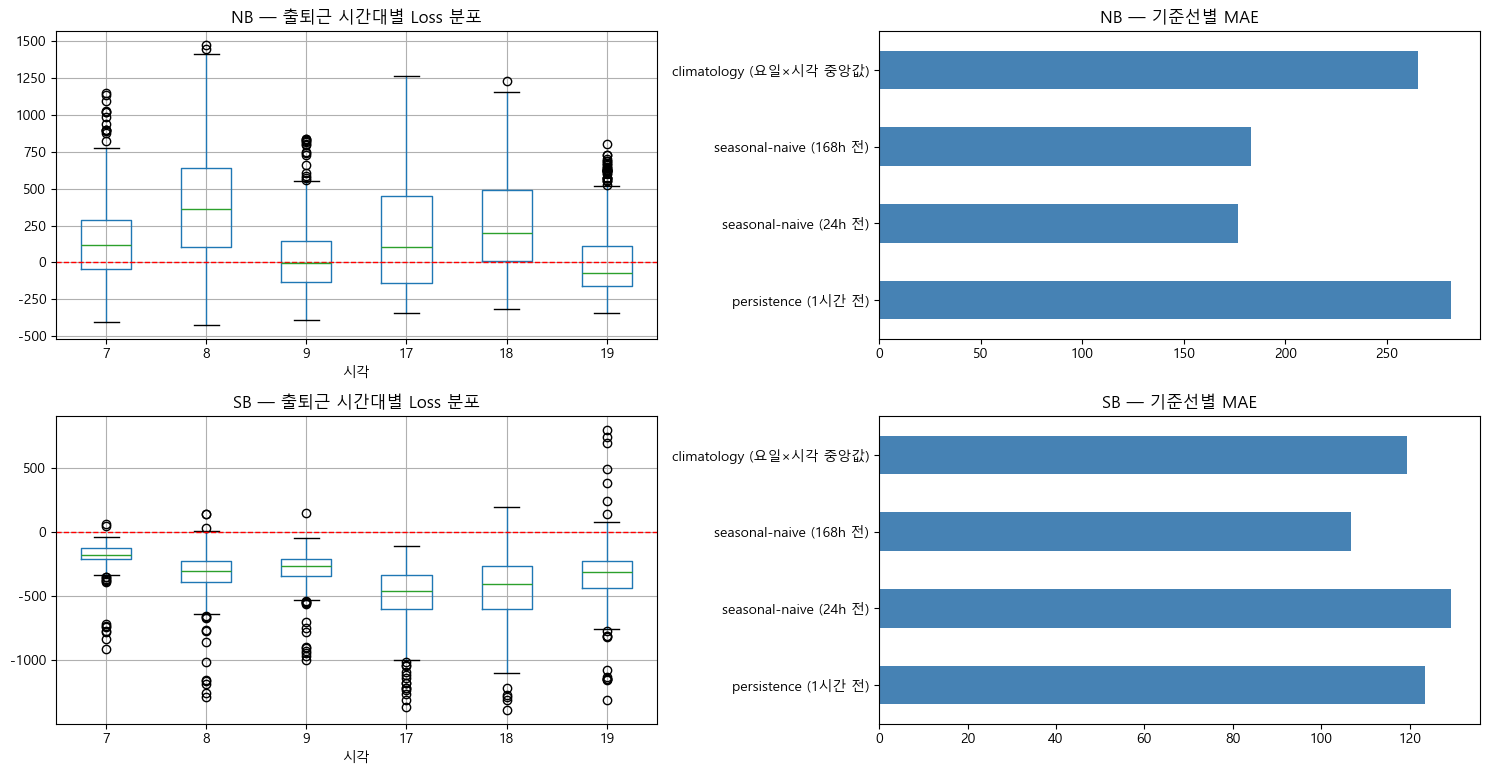

In [15]:
fig,axes=plt.subplots(2,2,figsize=(15,8))
for i,col in enumerate(["NB","SB"]):
    c=L[L.commute&L[col].notna()]
    c.boxplot(column=col,by="hour",ax=axes[i,0])
    axes[i,0].axhline(0,color="r",ls="--",lw=1)
    axes[i,0].set_title(f"{col} — 출퇴근 시간대별 Loss 분포"); axes[i,0].set_xlabel("시각")
    res[res.방향==col].set_index("기준선")["MAE"].plot(kind="barh",ax=axes[i,1],color="steelblue")
    axes[i,1].set_title(f"{col} — 기준선별 MAE"); axes[i,1].set_ylabel("")
plt.suptitle(""); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,"01_기준선비교.png"),dpi=110,bbox_inches="tight")
plt.show()

### 채택 기준선

MAE 만 보면 다른 기준선이 근소하게 나을 수 있으나, RMSE 가 나쁘면
**간헐적으로 큰 오차가 난다**는 뜻이다. 교통 운영에서는 평균 정확도보다
큰 오차의 억제가 중요하고, 두 방향을 같은 기준선으로 통일해야 비교도 공정하다.

→ **두 방향 모두 seasonal-naive (24h 전) 로 통일**한다.

In [16]:
sec("8. 채택 기준선")
print("[참고] MAE 기준 기계적 최저값")
print(res.loc[res.groupby("방향")["MAE"].idxmin()].round(3).to_string(index=False))
FINAL="seasonal-naive (24h 전)"
print(f"\n[최종 채택] 두 방향 모두 '{FINAL}'")
print(res[res.기준선==FINAL].round(3).to_string(index=False))
print("\n앞으로 만들 모델은 위 MAE 를 반드시 넘어야 의미가 있다.")
L.to_pickle(os.path.join(OUT_DIR,"L_loss.pkl"))
print("\n생성 파일:", sorted(os.listdir(OUT_DIR)))
save_log(os.path.join(OUT_DIR,"01_기준선결과.txt"))


8. 채택 기준선
[참고] MAE 기준 기계적 최저값
방향                     기준선   n     MAE    RMSE    R2
NB  seasonal-naive (24h 전) 670 176.966 257.238 0.215
SB seasonal-naive (168h 전) 325 106.745 169.481 0.118

[최종 채택] 두 방향 모두 'seasonal-naive (24h 전)'
방향                    기준선   n     MAE    RMSE     R2
NB seasonal-naive (24h 전) 670 176.966 257.238  0.215
SB seasonal-naive (24h 전) 325 129.458 189.012 -0.097

앞으로 만들 모델은 위 MAE 를 반드시 넘어야 의미가 있다.

생성 파일: ['01_기준선결과.txt', '01_기준선비교.png', '01_기준선성능.csv', 'L_loss.pkl']
로그 저장: ../outputs/01_기준선\01_기준선결과.txt  (93줄)
